# DQN on Atari Pong — from Scratch

A from-scratch implementation of Deep Q-Networks (Mnih et al., 2015), trained to play Atari Pong
directly from pixels, built up in stages: raw environment exploration, frame preprocessing, a replay
buffer, the convolutional Q-network, epsilon-greedy action selection, and finally the full agent with
a target network and training loop.

The agent was trained for ~2,000,000 environment steps; four checkpoints along the way
(`checkpoint_step0.pt`, `checkpoint_step500000.pt`, `checkpoint_step1000000.pt`,
`checkpoint_step1950000.pt`) are included so the evaluation section below can load and re-evaluate
them directly, without needing to retrain.

## Step 1: Explore the Raw Environment

In [ ]:
pip install -q gymnasium[atari,accept-rom-license] ale-py

In [2]:
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt
from collections import deque
import numpy as np
import cv2
import torch
import torch.nn as nn

gym.register_envs(ale_py)  # registers ALE/* environments with gymnasium


In [3]:
# render_mode="rgb_array" lets us grab frames as numpy arrays for inline display (works
# headlessly, e.g. in this notebook or on Colab). For an interactive window on your own
# machine instead, use render_mode="human":
#   env = gym.make("ALE/Pong-v5", render_mode="human")
env = gym.make("ALE/Pong-v5", render_mode="rgb_array")


A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


In [4]:
observation, info = env.reset()


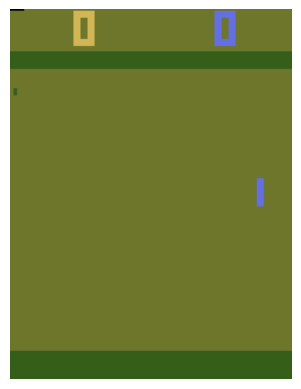

In [5]:
frame = env.render()  # returns a (210, 160, 3) numpy array
plt.imshow(frame)
plt.axis("off")
plt.show()


In [6]:
action = env.action_space.sample()
observation, reward, terminated, truncated, info = env.step(action)


In [7]:
def observe():
    frame = env.render()
    plt.imshow(frame)
    plt.axis("off")
    plt.show()


Total reward over 20 random steps: 0.0


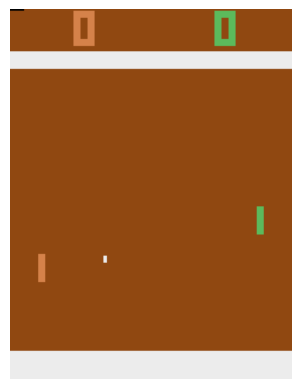

In [8]:
loop = 20
R = 0
for _ in range(loop):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    R += reward

    if terminated or truncated:
        print("terminated or truncated")
        observation, info = env.reset()

print(f"Total reward over {loop} random steps: {R}")
observe()
env.close()


## Step 2: Preprocess a Single Frame

In [9]:
def preprocess_frame(frame):
    """RGB frame -> grayscale, resized to 84x84 (standard DQN preprocessing)."""
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    return resized


In [10]:
class FrameStack:
    """Stacks the last `num_frames` preprocessed frames so the network can perceive motion."""

    def __init__(self, num_frames=4):
        self.frames = deque(maxlen=num_frames)

    def reset(self, frame):
        for _ in range(self.frames.maxlen):
            self.frames.append(frame)
        return np.stack(self.frames, axis=0)

    def append(self, frame):
        self.frames.append(frame)
        return np.stack(self.frames, axis=0)


In [11]:
class FrameSkip:
    """Repeats an action for `skip` frames and returns the max of the last two raw frames
    (standard Atari preprocessing, to handle flickering sprites)."""

    def __init__(self, env, skip=4):
        self.env = env
        self.skip = skip

    def reset(self):
        return self.env.reset()

    def step(self, action):
        buffer = deque(maxlen=2)
        total_reward = 0
        for _ in range(self.skip):
            observation, reward, terminated, truncated, info = self.env.step(action)
            total_reward += reward
            buffer.append(observation)

            if terminated or truncated:
                break

        if len(buffer) == 1:
            max_frame = buffer[-1]
        else:
            max_frame = np.maximum(buffer[0], buffer[1])

        return max_frame, total_reward, terminated, truncated


In [12]:
class PongEnv:
    """Wraps a raw ALE Pong env with frame skipping, preprocessing, and frame stacking."""

    def __init__(self, env, skip=4, num_frames=4):
        self.skip_env = FrameSkip(env, skip=skip)
        self.stacker = FrameStack(num_frames=num_frames)

    def reset(self):
        observation, info = self.skip_env.reset()
        processed = preprocess_frame(observation)
        return self.stacker.reset(processed)

    def step(self, action):
        max_frame, reward, terminated, truncated = self.skip_env.step(action)
        processed = preprocess_frame(max_frame)
        state = self.stacker.append(processed)
        return state, reward, terminated, truncated


In [13]:
#checking if the classes work
env = gym.make("ALE/Pong-v5")
pong_env = PongEnv(env, skip=4, num_frames=4)

state = pong_env.reset()
print(state.shape, state.dtype)  # expect (4, 84, 84)

for _ in range(10):
    action = env.action_space.sample()
    state, reward, terminated, truncated = pong_env.step(action)

print("Sanity check passed: PongEnv wrapper runs end to end.")


(4, 84, 84) uint8
Sanity check passed: PongEnv wrapper runs end to end.


## Step 3: Replay Buffer

In [15]:
class ReplayBuffer:
    """Fixed-capacity circular buffer of (state, action, reward, next_state, done) transitions."""

    def __init__(self, capacity, state_shape=(4, 84, 84), device="cpu"):
        self.capacity = capacity
        self.device = device

        self.states = np.zeros((capacity, *state_shape), dtype=np.uint8)
        self.next_states = np.zeros((capacity, *state_shape), dtype=np.uint8)
        self.actions = np.zeros((capacity,), dtype=np.int32)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.float32)

        self.pos = 0
        self.size = 0

    def push(self, state, action, reward, next_state, done):
        self.states[self.pos] = state
        self.next_states[self.pos] = next_state
        self.actions[self.pos] = action
        self.rewards[self.pos] = reward
        self.dones[self.pos] = done

        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idxs = np.random.randint(0, self.size, size=batch_size)

        states = torch.from_numpy(self.states[idxs]).to(self.device).float() / 255.0
        next_states = torch.from_numpy(self.next_states[idxs]).to(self.device).float() / 255.0
        actions = torch.from_numpy(self.actions[idxs]).to(self.device)
        rewards = torch.from_numpy(self.rewards[idxs]).to(self.device)
        dones = torch.from_numpy(self.dones[idxs]).to(self.device)

        return states, actions, rewards, next_states, dones


In [16]:
#checking if the class works

buf = ReplayBuffer(capacity=1000, state_shape=(4, 84, 84))
for i in range(50):
    dummy_state = np.random.randint(0, 255, (4, 84, 84), dtype=np.uint8)
    buf.push(dummy_state, action=np.random.randint(6), reward=0.0, next_state=dummy_state, done=False)

states, actions, rewards, next_states, dones = buf.sample(16)
print(states.shape, states.dtype)   # expect torch.Size([16, 4, 84, 84]) torch.float32
print(states.max().item(), states.min().item())   # expect values between 0 and 1


torch.Size([16, 4, 84, 84]) torch.float32
0.9960784316062927 0.0


## Step 4: The Q-Network (CNN)

In [17]:
class DQN(nn.Module):
    """The standard Nature DQN convolutional architecture (Mnih et al., 2015)."""

    def __init__(self, num_actions):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=4, out_channels=32, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1)

        self.fc1 = nn.Linear(in_features=7 * 7 * 64, out_features=512)
        self.fc2 = nn.Linear(in_features=512, out_features=num_actions)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.relu(self.conv3(x))

        x = x.reshape(x.shape[0], -1)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [18]:
#checking if the class works

model = DQN(num_actions=6)
dummy_input = torch.rand(2, 4, 84, 84)  # batch of 2 fake states
output = model(dummy_input)
print(output.shape)  # expect torch.Size([2, 6])


torch.Size([2, 6])


## Step 5: Epsilon-Greedy Action Selection

In [19]:
def select_action(state, model, epsilon, num_actions):
    a = np.random.random()
    if a < epsilon:
        return np.random.randint(num_actions)
    else:
        with torch.no_grad():
            state = torch.from_numpy(state).float().unsqueeze(0) / 255.0  # normalizing
            q_values = model(state)
            return torch.argmax(q_values).item()


In [20]:
#checking

model = DQN(num_actions=6)
dummy_state = np.random.randint(0, 255, (4, 84, 84), dtype=np.uint8)

# with epsilon=1.0, should always be random
actions = [select_action(dummy_state, model, epsilon=1.0, num_actions=6) for _ in range(20)]
print(actions)  # expect varied values 0-5

# with epsilon=0.0, should always pick the same action (greedy, same state/model every time)
actions = [select_action(dummy_state, model, epsilon=0.0, num_actions=6) for _ in range(5)]
print(actions)  # expect the SAME value repeated 5 times


[5, 3, 5, 5, 0, 4, 4, 3, 5, 2, 4, 5, 2, 2, 0, 4, 3, 4, 4, 1]
[4, 4, 4, 4, 4]


In [21]:
def get_epsilon(current_step, eps_start=1.0, eps_end=0.1, eps_decay_steps=1_000_000):
    """Linear epsilon decay from eps_start to eps_end over eps_decay_steps."""
    frac = min(1.0, current_step / eps_decay_steps)
    epsilon = eps_start + frac * (eps_end - eps_start)
    return epsilon


In [22]:
#checking

for step in [0, 500_000, 1_000_000, 2_000_000]:
    epsilon = get_epsilon(current_step=step, eps_start=1.0, eps_end=0.1, eps_decay_steps=1_000_000)
    print(f"step={step:>10}  epsilon={epsilon:.3f}")


step=         0  epsilon=1.000
step=    500000  epsilon=0.550
step=   1000000  epsilon=0.100
step=   2000000  epsilon=0.100


## Step 6: The DQNAgent Class

Combines the network, target network, optimizer, and epsilon-greedy policy into one agent, with
checkpointing support.

In [23]:
class DQNAgent:
    def __init__(self, num_actions, device="cpu", lr=1e-4, gamma=0.99, target_sync_every=10000):
        self.num_actions = num_actions
        self.device = device
        self.gamma = gamma
        self.target_sync_every = target_sync_every

        self.policy_net = DQN(num_actions).to(device)
        self.target_net = DQN(num_actions).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        self.steps_done = 0
        self.update_count = 0

    def select_action(self, state, greedy=False):
        if not greedy:
            epsilon = get_epsilon(self.steps_done, eps_start=1.0, eps_end=0.1, eps_decay_steps=1_000_000)
            a = np.random.random()
        else:
            epsilon = 0  # greedy always takes the else branch below regardless of epsilon

        if not greedy and a < epsilon:
            action = np.random.randint(self.num_actions)
        else:
            with torch.no_grad():
                state_t = torch.from_numpy(state).float().unsqueeze(0).to(self.device) / 255.0
                q_values = self.policy_net(state_t)
                action = torch.argmax(q_values).item()

        if not greedy:
            self.steps_done += 1

        return action

    def update(self, batch):
        """One gradient step of Q-learning with a target network: minimizes the Bellman residual."""
        states, actions, rewards, next_states, dones = batch
        q_values = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0]
            target_q_values = rewards + (1 - dones) * self.gamma * next_q_values

        loss = self.loss_fn(q_values, target_q_values)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_count += 1
        if self.update_count % self.target_sync_every == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def save(self, path):
        torch.save({
            "policy_net": self.policy_net.state_dict(),
            "target_net": self.target_net.state_dict(),
            "optimizer": self.optimizer.state_dict(),
            "steps_done": self.steps_done,
            "update_count": self.update_count,
        }, path)

    def load(self, path, map_location=None):
        checkpoint = torch.load(path, map_location=map_location or self.device)
        self.policy_net.load_state_dict(checkpoint["policy_net"])
        self.target_net.load_state_dict(checkpoint["target_net"])
        self.optimizer.load_state_dict(checkpoint["optimizer"])
        self.steps_done = checkpoint["steps_done"]
        self.update_count = checkpoint["update_count"]


In [24]:
agent = DQNAgent(num_actions=6, device="cpu")
dummy_state = np.random.randint(0, 255, (4, 84, 84), dtype=np.uint8)

before = agent.steps_done
for _ in range(10):
    agent.select_action(dummy_state, greedy=True)
print("steps_done after greedy calls:", agent.steps_done)  # should be UNCHANGED from before


steps_done after greedy calls: 0


In [25]:
agent = DQNAgent(num_actions=6, device="cpu")
agent.steps_done = 12345  # fake some progress
agent.save("test_checkpoint.pt")

agent2 = DQNAgent(num_actions=6, device="cpu")
print(agent2.steps_done)  # should be 0, fresh agent

agent2.load("test_checkpoint.pt")
print(agent2.steps_done)  # should now be 12345, restored from checkpoint


0
12345


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
agent = DQNAgent(num_actions=6, device=device)  # trained on a Colab GPU


In [27]:
batch_size = 8
states = torch.rand(batch_size, 4, 84, 84)
actions = torch.randint(0, 6, (batch_size,))
rewards = torch.rand(batch_size)
next_states = torch.rand(batch_size, 4, 84, 84)
dones = torch.zeros(batch_size)
batch = (states, actions, rewards, next_states, dones)

for i in range(5):
    before = agent.policy_net.conv1.weight.clone()
    agent.update(batch)
    after = agent.policy_net.conv1.weight
    changed = not torch.equal(before, after)
    print(f"update {i + 1}: policy_net changed = {changed}")


update 1: policy_net changed = True
update 2: policy_net changed = True
update 3: policy_net changed = True
update 4: policy_net changed = True


update 5: policy_net changed = True


## Training

The full training loop below ran for 2,000,000 environment steps (several hours on a Colab GPU) —
it's included here for completeness but **wasn't re-run to produce this notebook**; the checkpoints and
learning-progress plot it produced are loaded and displayed in the next section instead.

In [ ]:
env = gym.make("ALE/Pong-v5")
pong_env = PongEnv(env, skip=4, num_frames=4)

eval_raw_env = gym.make("ALE/Pong-v5")
eval_env = PongEnv(eval_raw_env, skip=4, num_frames=4)

device = "cuda" if torch.cuda.is_available() else "cpu"

buffer = ReplayBuffer(capacity=100_000, state_shape=(4, 84, 84), device=device)
agent = DQNAgent(num_actions=pong_env.skip_env.env.action_space.n, device=device)

state = pong_env.reset()

replay_start_size = 10_000  # steps of pure exploration before training starts
batch_size = 32
train_every = 4             # gradient step every 4 env steps
eval_every = 50_000          # steps between evaluation checkpoints
total_steps = 2_000_000

episode_reward = 0
recent_rewards = deque(maxlen=20)
eval_steps = []
eval_rewards = []

for step in range(total_steps):
    action = agent.select_action(state)
    next_state, reward, terminated, truncated = pong_env.step(action)

    done = terminated or truncated
    buffer.push(state, action, reward, next_state, done)

    state = next_state
    episode_reward += reward

    if buffer.size >= replay_start_size:
        if step % train_every == 0:
            batch = buffer.sample(batch_size)
            agent.update(batch)

    if done:
        state = pong_env.reset()
        recent_rewards.append(episode_reward)
        avg_reward = sum(recent_rewards) / len(recent_rewards)
        print(f"step:{step}, episode reward: {episode_reward}, avg(20): {avg_reward:.2f}")
        episode_reward = 0

    if step % eval_every == 0:
        avg_eval_reward = evaluate(agent, eval_env, num_episodes=5)
        print(f"[eval] step={step}, avg_reward over 5 episodes: {avg_eval_reward:.2f}")
        agent.save(f"checkpoint_step{step}.pt")
        eval_steps.append(step)
        eval_rewards.append(avg_eval_reward)


### Actual Training Result

The plot below is the real output of the training run above.

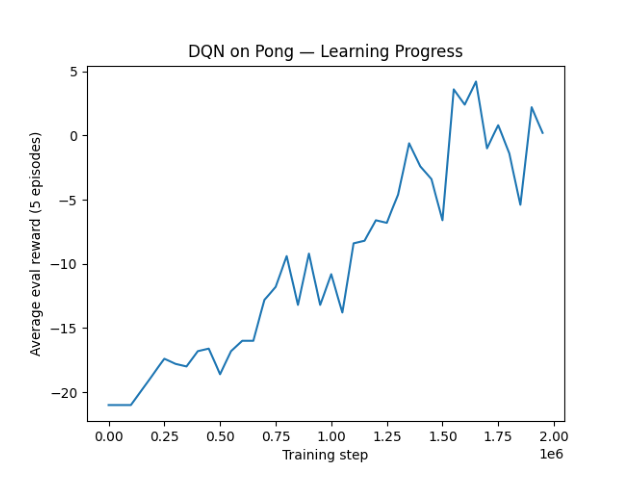

In [29]:
img = plt.imread("training_progress.png")
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()


## Evaluation

Rather than re-running the multi-hour training loop, we load each saved checkpoint and evaluate it
for real, right here, to check that performance actually improved over training and that the
checkpoints reproduce the trend in the plot above.

We use `render_mode="rgb_array"` rather than `"human"` since a pop-up game window isn't reproducible
in a notebook — to actually *watch* the trained agent play with a live window, run this same
evaluation locally with `render_mode="human"` instead.

In [30]:
def evaluate(agent, pong_env, num_episodes=5, max_steps=3000):
    """Runs the agent greedily for num_episodes and returns the average total reward."""
    total_rewards = []
    for _ in range(num_episodes):
        state = pong_env.reset()
        episode_reward = 0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.select_action(state, greedy=True)
            state, reward, terminated, truncated = pong_env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1
        total_rewards.append(episode_reward)

    return sum(total_rewards) / len(total_rewards)


In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_paths = [
    "checkpoint_step0.pt",
    "checkpoint_step500000.pt",
    "checkpoint_step1000000.pt",
    "checkpoint_step1950000.pt",
]

watch_env = gym.make("ALE/Pong-v5", render_mode="rgb_array")
watch_pong_env = PongEnv(watch_env, skip=4, num_frames=4)

results = []
for checkpoint_path in checkpoint_paths:
    agent = DQNAgent(num_actions=6, device=device)
    agent.load(checkpoint_path, map_location=device)

    avg_reward = evaluate(agent, watch_pong_env, num_episodes=10)
    print(f"{checkpoint_path}: average reward over 10 episodes = {avg_reward:.2f}")
    results.append((checkpoint_path, avg_reward))


checkpoint_step0.pt: average reward over 10 episodes = -21.00


checkpoint_step500000.pt: average reward over 10 episodes = -17.20


checkpoint_step1000000.pt: average reward over 10 episodes = -5.10


checkpoint_step1950000.pt: average reward over 10 episodes = 4.00


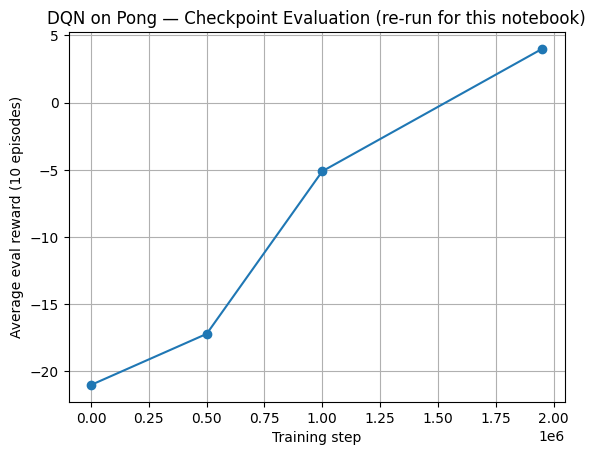

In [32]:
steps = [0, 500_000, 1_000_000, 1_950_000]
rewards = [r for _, r in results]

plt.plot(steps, rewards, marker='o')
plt.xlabel("Training step")
plt.ylabel("Average eval reward (10 episodes)")
plt.title("DQN on Pong — Checkpoint Evaluation (re-run for this notebook)")
plt.grid(True)
plt.show()
